In [1]:
import pandas as pd

df = pd.read_csv("../../../Data/Question-Answer.csv").sample(500)
df.drop(columns=['distractor'],inplace=True)
df

,question,answer_text
25990,What can we infer from the passage ?,The president of the company is a responsible ...
28446,Which of the following can best describe the m...,The expectations of partners and financial pre...
8403,What examples does the writer give of unhealth...,"Gym - going , strange dieting methods , eating..."
25182,What would be the best title for the text ?,We have to be more energy efficient
10470,Which of the following is NOT the purpose of t...,To win a race on the water .
...,...,...
22160,Jim Hatfield decided to become a do - it - you...,his car repairs cost too much
5936,What 's FALSE according to the passage ?,Finland is heaven for immoral people because t...
7835,"According to the author , which of the followi...",Do n't try to review everything you have learn...
26169,What might the author most probably continue t...,What one should avoid in building self - confi...


# 1. Tokenization

In [2]:
def clean_sentence(text):
    return (
        text
        .replace("?","")
        .replace("!","")
        .replace("'","")
        .replace(",","")
        .replace(".","")
        .replace(":","")
        .replace("(","")
        .replace(")","")
    )

In [3]:
clean_sentence("What can we learn about Friends")

'What can we learn about Friends'

In [4]:
document = []
def text_document(row):
    question = clean_sentence(row['question'])
    answer = clean_sentence(row['answer_text'])
    
    merge_tokens = question + answer
    
    document.append(merge_tokens)

In [5]:
df.apply(text_document, axis=1)
document

['What can we infer from the passage The president of the company is a responsible person ',
 'Which of the following can best describe the main idea of the passage The expectations of partners and financial pressure may prevent a relationship ',
 'What examples does the writer give of unhealthy weight - loss methods in the East and West Gym - going  strange dieting methods  eating disorders and taking pills ',
 'What would be the best title for the text We have to be more energy efficient',
 'Which of the following is NOT the purpose of the journey To win a race on the water ',
 'To everyone s surprise  Jack has been employed by a big company  about which we can say  "  Every dog has its day',
 'We can learn from the passage that it is mainly abouttaking exams online',
 'Which of the following is written in a poetic style Out of the Dust ',
 'What can be a suitable title for the passage Hugs Having Healing Power',
 'The author writes the passage mainlyto remind people of negative effe

# 2. Build vocab

In [6]:
vocab = {
    "UNK":0
}

In [7]:
from nltk.tokenize import word_tokenize
for sentence in document:
    tokenized_word = word_tokenize(sentence)
    for token in tokenized_word:
        if token not in vocab:
            vocab[token] = len(vocab)

In [8]:
print(len(vocab))
vocab

2332


{'UNK': 0,
 'What': 1,
 'can': 2,
 'we': 3,
 'infer': 4,
 'from': 5,
 'the': 6,
 'passage': 7,
 'The': 8,
 'president': 9,
 'of': 10,
 'company': 11,
 'is': 12,
 'a': 13,
 'responsible': 14,
 'person': 15,
 'Which': 16,
 'following': 17,
 'best': 18,
 'describe': 19,
 'main': 20,
 'idea': 21,
 'expectations': 22,
 'partners': 23,
 'and': 24,
 'financial': 25,
 'pressure': 26,
 'may': 27,
 'prevent': 28,
 'relationship': 29,
 'examples': 30,
 'does': 31,
 'writer': 32,
 'give': 33,
 'unhealthy': 34,
 'weight': 35,
 '-': 36,
 'loss': 37,
 'methods': 38,
 'in': 39,
 'East': 40,
 'West': 41,
 'Gym': 42,
 'going': 43,
 'strange': 44,
 'dieting': 45,
 'eating': 46,
 'disorders': 47,
 'taking': 48,
 'pills': 49,
 'would': 50,
 'be': 51,
 'title': 52,
 'for': 53,
 'text': 54,
 'We': 55,
 'have': 56,
 'to': 57,
 'more': 58,
 'energy': 59,
 'efficient': 60,
 'NOT': 61,
 'purpose': 62,
 'journey': 63,
 'To': 64,
 'win': 65,
 'race': 66,
 'on': 67,
 'water': 68,
 'everyone': 69,
 's': 70,
 'surpri

# 3. Text to numeric representation

In [9]:
def line_to_numeric_rep(sentence, vocab):
    numerical_present = []
    for word in word_tokenize(sentence):
        if word in vocab:
            numerical_present.append(vocab[word])
        else:
            numerical_present.append(0)
    return numerical_present

In [10]:
line_to_numeric_rep("What can we learn about Friends",vocab)

[1, 2, 3, 86, 78, 0]

In [11]:
numerical_document = []
for sentence in document:
    numerical_document.append(line_to_numeric_rep(sentence,vocab))

numerical_document

[[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 6, 11, 12, 13, 14, 15],
 [16,
  10,
  6,
  17,
  2,
  18,
  19,
  6,
  20,
  21,
  10,
  6,
  7,
  8,
  22,
  10,
  23,
  24,
  25,
  26,
  27,
  28,
  13,
  29],
 [1,
  30,
  31,
  6,
  32,
  33,
  10,
  34,
  35,
  36,
  37,
  38,
  39,
  6,
  40,
  24,
  41,
  42,
  36,
  43,
  44,
  45,
  38,
  46,
  47,
  24,
  48,
  49],
 [1, 50, 51, 6, 18, 52, 53, 6, 54, 55, 56, 57, 51, 58, 59, 60],
 [16, 10, 6, 17, 12, 61, 6, 62, 10, 6, 63, 64, 65, 13, 66, 67, 6, 68],
 [64,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  13,
  77,
  11,
  78,
  79,
  3,
  2,
  80,
  81,
  82,
  83,
  73,
  84,
  85],
 [55, 2, 86, 5, 6, 7, 87, 88, 12, 89, 90, 91, 92],
 [16, 10, 6, 17, 12, 93, 39, 13, 94, 95, 96, 10, 6, 97],
 [1, 2, 51, 13, 98, 52, 53, 6, 7, 99, 100, 101, 102],
 [8, 103, 104, 6, 7, 105, 106, 107, 10, 108, 109, 10, 110],
 [8,
  111,
  10,
  13,
  112,
  113,
  53,
  107,
  57,
  114,
  115,
  116,
  117,
  53,
  118,
  119,
  120,
  107],
 [1, 121, 122, 6, 103, 8

# 4. Next Word Prediction Format

In [12]:
next_word_prediction_data = []

for numerical_sentence in numerical_document:
    for i in range(1, len(numerical_sentence)):
        next_word_prediction_data.append(numerical_sentence[:i+1])

next_word_prediction_data

[[1, 2],
 [1, 2, 3],
 [1, 2, 3, 4],
 [1, 2, 3, 4, 5],
 [1, 2, 3, 4, 5, 6],
 [1, 2, 3, 4, 5, 6, 7],
 [1, 2, 3, 4, 5, 6, 7, 8],
 [1, 2, 3, 4, 5, 6, 7, 8, 9],
 [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 6],
 [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 6, 11],
 [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 6, 11, 12],
 [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 6, 11, 12, 13],
 [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 6, 11, 12, 13, 14],
 [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 6, 11, 12, 13, 14, 15],
 [16, 10],
 [16, 10, 6],
 [16, 10, 6, 17],
 [16, 10, 6, 17, 2],
 [16, 10, 6, 17, 2, 18],
 [16, 10, 6, 17, 2, 18, 19],
 [16, 10, 6, 17, 2, 18, 19, 6],
 [16, 10, 6, 17, 2, 18, 19, 6, 20],
 [16, 10, 6, 17, 2, 18, 19, 6, 20, 21],
 [16, 10, 6, 17, 2, 18, 19, 6, 20, 21, 10],
 [16, 10, 6, 17, 2, 18, 19, 6, 20, 21, 10, 6],
 [16, 10, 6, 17, 2, 18, 19, 6, 20, 21, 10, 6, 7],
 [16, 10, 6, 17, 2, 18, 19, 6, 20, 21, 10, 6, 7, 8],
 [16, 10, 6, 17, 2, 18, 19, 6, 20, 21, 10, 6, 7, 8, 22],
 [16, 10, 6, 17, 2, 18, 19, 6, 20, 21, 10, 6, 7, 8,

# 5. Left Padding

In [13]:
maxi = 0
for seq in next_word_prediction_data:
    maxi = max(maxi, len(seq))
    
maxi

32

In [14]:
next_word_prediction_data_padded = []
for sequence in next_word_prediction_data:
    next_word_prediction_data_padded.append([0]*(maxi - len(sequence)) + sequence)
    
next_word_prediction_data_padded

[[0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  2],
 [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  2,
  3],
 [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  2,
  3,
  4],
 [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  2,
  3,
  4,
  5],
 [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  2,
  3,
  4,
  5,
  6],
 [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  2,
  3,
  4,
  5,
  6,
  7],
 [0,
  0,
  0,
  0,
  0,
  0,
  0,

# 4. Dataloader

In [15]:
import torch

data_tensor = torch.tensor(next_word_prediction_data_padded, dtype=torch.long)
data_tensor

tensor([[   0,    0,    0,  ...,    0,    1,    2],
        [   0,    0,    0,  ...,    1,    2,    3],
        [   0,    0,    0,  ...,    2,    3,    4],
        ...,
        [   0,    0,    0,  ..., 2329, 2330,  643],
        [   0,    0,    0,  ..., 2330,  643,   70],
        [   0,    0,    0,  ...,  643,   70, 2331]])

In [16]:
X = data_tensor[:, :-1]
y = data_tensor[:, -1]

In [17]:
from torch.utils.data import Dataset, DataLoader
import torch

class CustomDataset(Dataset):
    def __init__(self, X,y):
        self.X = X
        self.y = y
        
    def __len__(self):
        return self.X.shape[0]
    
    def __getitem__(self, index):
        return self.X[index], self.y[index]

In [18]:
dataset = CustomDataset(X,y)

dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

In [19]:
for ques, ans in dataloader:
    print(ques)
    print(ans)
    break

tensor([[   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,   55,  407,    4,    5,    6,    7,  408,
          363,  409,   56,  410,  109,   67,  411],
        [   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    8,
           83, 2260, 2261, 2262,   87,  714,   31],
        [   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,  448,
           57,    6,    7,   79,   10,    6,   17],
        [   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    8,  585],
        [   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0, 

# 5. Model Build

In [20]:
import torch.nn as nn
class NextWordPredictorLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim = 50, hidden_dim=128, num_layers=2, dropout=0.3):
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim=embedding_dim, padding_idx=0)
        self.embedding_dropout = nn.Dropout(dropout)
        
        self.lstm = nn.LSTM(
            input_size= embedding_dim,
            hidden_size= hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=False,
            bias=True
        )
        
        # Regularization after LSTM
        self.layer_norm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)
        
        self.fc = nn.Linear(hidden_dim, vocab_size)
        
    def forward(self, question):
        embedding_ques = self.embedding_dropout(self.embedding(question))
        
        # LSTM returns (output, (hidden_state, cell_states)) — unpack both hidden & 
        lstm_output , (hidden_state, cell_states) = self.lstm(embedding_ques)
        
        # Take last layer's hidden state
        last_hidden = hidden_state[-1]
        
        # LayerNorm + Dropout
        last_hidden = self.layer_norm(last_hidden)
        last_hidden = self.dropout(last_hidden)
        
        return self.fc(last_hidden)

# 6. Train Model

In [29]:
learning_rate = 0.001
epochs = 100

In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [31]:
model = NextWordPredictorLSTM(len(vocab)).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [32]:
losses = []
for epoch in range(epochs):
    epochs_loss = 0
    for batch_question, batch_answer in dataloader:
        batch_question, batch_answer = batch_question.to(device), batch_answer.to(device)
        optimizer.zero_grad()
        
        y_pred = model(batch_question)
        
        loss = criterion(y_pred, batch_answer)
        
        loss.backward()
        
        optimizer.step()
        
        epochs_loss += loss.item()
        
    avg_epoch_loss = epochs_loss / len(dataloader)
    losses.append(avg_epoch_loss)
    print(f"Epoch {epoch+1}: Loss {avg_epoch_loss}")

Epoch 1: Loss 6.67440705139096
Epoch 2: Loss 5.967522859573364
Epoch 3: Loss 5.54625221661159
Epoch 4: Loss 5.205664698817149
Epoch 5: Loss 4.87414707656668
Epoch 6: Loss 4.577138584201076
Epoch 7: Loss 4.272985626669491
Epoch 8: Loss 3.987493586139519
Epoch 9: Loss 3.7071518216814314
Epoch 10: Loss 3.454464002817619
Epoch 11: Loss 3.253336101019082
Epoch 12: Loss 3.023024150303432
Epoch 13: Loss 2.8302912241270564
Epoch 14: Loss 2.6577676569714264
Epoch 15: Loss 2.526015734973074
Epoch 16: Loss 2.391622547341996
Epoch 17: Loss 2.299247890460391
Epoch 18: Loss 2.2226894903583685
Epoch 19: Loss 2.129395845557461
Epoch 20: Loss 2.0480272584602615
Epoch 21: Loss 1.9640735187450378
Epoch 22: Loss 1.8861792408117728
Epoch 23: Loss 1.8089986193079908
Epoch 24: Loss 1.7566349210859347
Epoch 25: Loss 1.704683863816141
Epoch 26: Loss 1.6731505424034696
Epoch 27: Loss 1.6040920131847638
Epoch 28: Loss 1.5490045800429433
Epoch 29: Loss 1.5470284058266328
Epoch 30: Loss 1.507783036272065
Epoch 31:

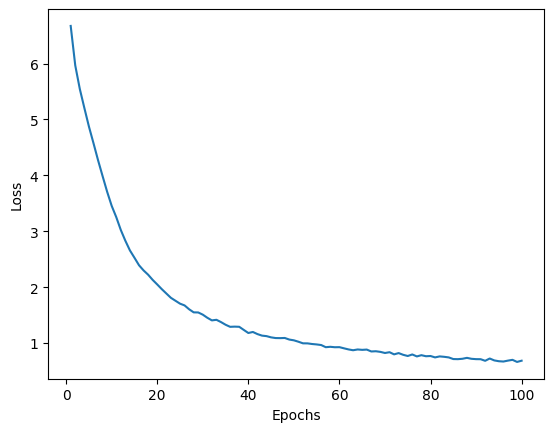

In [33]:
import matplotlib.pyplot as plt

plt.plot(range(1,epochs+1), losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

# 7. Inference

In [34]:
def predict(question, threshold=0.5, words=1):
    # tokenize 
    tokens = word_tokenize(question.lower())
    
    # convert text to number
    numerical_question = line_to_numeric_rep(question, vocab)
    
    # padding
    numerical_question_padded = [0]*(maxi - len(numerical_question)) + numerical_question
    
    # make it tensor (push into gpu)
    tensor_question = torch.tensor(numerical_question_padded, dtype=torch.long).unsqueeze(0).to(device)
    
    # probabilities
    output_probability = model(tensor_question)
    
    # use softmax
    probs = torch.nn.functional.softmax(output_probability, dim=1)
    
    # get max probs
    max_probs, max_indexes = torch.topk(probs,k=words, dim=1)
    
    inverse_vocab = {value:key for key, value in vocab.items()}
    
    response = {
        "Ans" : "",
        "confidence" : []
    }

    for prob, index in zip(max_probs[0], max_indexes[0]):

        response['Ans'] += inverse_vocab[index.item()]
        response['Ans'] += " "
        response['confidence'].append(round(prob.item(), 4))
    
    return response['Ans'], response['confidence']

In [35]:
predict("Jane Armstrong",words=5, threshold=0.5)

('posting was gain will up ', [0.3109, 0.2457, 0.2014, 0.0675, 0.0167])

In [36]:
df

,question,answer_text
25990,What can we infer from the passage ?,The president of the company is a responsible ...
28446,Which of the following can best describe the m...,The expectations of partners and financial pre...
8403,What examples does the writer give of unhealth...,"Gym - going , strange dieting methods , eating..."
25182,What would be the best title for the text ?,We have to be more energy efficient
10470,Which of the following is NOT the purpose of t...,To win a race on the water .
...,...,...
22160,Jim Hatfield decided to become a do - it - you...,his car repairs cost too much
5936,What 's FALSE according to the passage ?,Finland is heaven for immoral people because t...
7835,"According to the author , which of the followi...",Do n't try to review everything you have learn...
26169,What might the author most probably continue t...,What one should avoid in building self - confi...
